# Automatidate Project
Regression Analysis: Simplify complex data relationships

# Multiple linear regression model

- Previously, we have completed an initial Python coding work, EDA, and A/B testing and now 

- The new client of Automatidata, the NYC Taxi and Limousine Commission (New York City TLC), wants the Automatidata team to build a multiple linear regression model to predict taxi fares using existing data that was collected over the course of a year.

- Mmultiple linear regression helps you estimate the linear relationship between one continuous dependent variable and two or more independent variables.

**The purpose** of this project is to demostrate knowledge of EDA and a multiple linear regression model

**The goal** is to build a multiple linear regression model and evaluate the model

**This activity has three parts:**

**Part 1:** Exploratory Data Analysis (EDA) & Checking Model Assumptions

**Part 2:** Model Building and evaluation

**Part 3:** Interpreting Model Results
- Key insights emerged from the model
- Business recommendations proposed based on the models built

# Build a multiple linear regression model

### Task 1. Imports and loading
Import the packages that are needed for building linear regression models.

In [234]:
# Imports
# Packages for numerics + dataframes
import pandas as pd
import numpy as np

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for date conversions for calculating trip durations
from datetime import datetime
from datetime import date
from datetime import timedelta

# Packages for OLS, MLR, confusion matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [235]:
df_1=pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv")

### Exploratory Data Analysis

In order to analyze our data we need to consider the following purposes of our EDA.
1.   Outliers and extreme data values can significantly impact linear regression equations. After visualizing data, make a plan for addressing outliers by dropping rows, substituting extreme data with average data, and/or removing data values greater than 3 standard deviations.

2.   EDA activities also include identifying missing data to help the analyst make decisions on their exclusion or inclusion by substituting values with data set means, medians, and other similar methods.

3.   It's important to check for things like multicollinearity between predictor variables, as well to understand their distributions, as this will help you decide what statistical inferences can be made from the model and which ones cannot.

4.  Additionally, it can be useful to engineer new features by multiplying variables together or taking the difference from one variable to another. For example, in this dataset you can create a `duration` variable by subtracting `tpep_dropoff` from `tpep_pickup time`.

### Task 2a. Explore data with EDA

Analyze and discover data, looking for correlations, missing data, outliers, and duplicates.

In [236]:
df = df_1.copy()

Checking for missing data and duplicates

In [237]:
print('Shape of dataframe :', df.shape)
print('Shape of dataframe after dropping duplicates :', df.drop_duplicates().shape)
print('Total number of missing values :', df.isna().sum())

Shape of dataframe : (22699, 18)
Shape of dataframe after dropping duplicates : (22699, 18)
Total number of missing values : Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64


There are no duplicates or missing values in the data.

In [238]:
# Descriptive statistics about the data
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


- There are clearly some outliers in several variables, like `tip_amount` (\$200) and `total_amount` (\$1,200).
- Some variables remain constant in the dataset like "mta_tax" which is 0.5 in the whole dataset. or "improvement_surcharge" which would imply that they would not be expected to be very predictive.

### Task 2b. Convert pickup & dropoff columns to datetime

In [239]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

Time related columns such as tpep_pickup_datetime and tpep_dropoff_datetime are object type and better to be converted into datetime types.  

In [241]:
df['tpep_pickup_datetime']

0         03/25/2017 8:55:43 AM
1         04/11/2017 2:53:28 PM
2         12/15/2017 7:26:56 AM
3         05/07/2017 1:17:59 PM
4        04/15/2017 11:32:20 PM
                  ...          
22694     02/24/2017 5:37:23 PM
22695     08/06/2017 4:43:59 PM
22696     09/04/2017 2:54:14 PM
22697    07/15/2017 12:56:30 PM
22698     03/02/2017 1:02:49 PM
Name: tpep_pickup_datetime, Length: 22699, dtype: object

In [242]:
# Converting pick up and drop off columns to date_time data type
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

### Task 2c. Create duration time column
Here, we wil create a duration column representing the trip duration of each taxi ride

In [243]:
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])

In [244]:
df['duration_min'] = df['duration'].dt.total_seconds() / 60

In [245]:
df['duration_min'] 

0        14.066667
1        26.500000
2         7.200000
3        30.250000
4        16.716667
           ...    
22694     3.266667
22695    40.800000
22696     4.133333
22697    11.933333
22698    13.333333
Name: duration_min, Length: 22699, dtype: float64

### Task 2d. Outliers

Let's use df.info() in order to inspect the columns and decide which ones to check for outliers.

In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   Unnamed: 0             22699 non-null  int64          
 1   VendorID               22699 non-null  int64          
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns] 
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns] 
 4   passenger_count        22699 non-null  int64          
 5   trip_distance          22699 non-null  float64        
 6   RatecodeID             22699 non-null  int64          
 7   store_and_fwd_flag     22699 non-null  object         
 8   PULocationID           22699 non-null  int64          
 9   DOLocationID           22699 non-null  int64          
 10  payment_type           22699 non-null  int64          
 11  fare_amount            22699 non-null  float64        
 12  extra                  22699 non-null  float64

In [247]:
df.describe()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,duration_min
count,2.269900e+04,22699.000000,22699,22699,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699,22699.000000
mean,5.675849e+07,1.556236,2017-06-29 07:32:48.973126656,2017-06-29 07:49:49.799726848,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502,0 days 00:17:00.826600290,17.013777
min,1.212700e+04,1.000000,2017-01-01 00:08:25,2017-01-01 00:17:20,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000,-1 days +23:43:01,-16.983333
25%,2.852056e+07,1.000000,2017-03-30 03:09:38.500000,2017-03-30 03:11:20.500000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000,0 days 00:06:39,6.650000
50%,5.673150e+07,2.000000,2017-06-23 12:35:57,2017-06-23 12:55:11,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000,0 days 00:11:11,11.183333
75%,8.537452e+07,2.000000,2017-10-02 10:34:34,2017-10-02 10:53:47,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000,0 days 00:18:23,18.383333
max,1.134863e+08,2.000000,2017-12-31 23:45:30,2017-12-31 23:49:24,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000,0 days 23:59:33,1439.550000
std,3.274493e+07,0.496838,NaN,NaN,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295,0 days 01:01:59.788923306,61.996482


We should mention that not all the columns will be used for prediction. Thee most important columns to check for outliers are as follow: 
- "trip_distance"
- "fare_amount"
- "duration_min"

### Boxplots

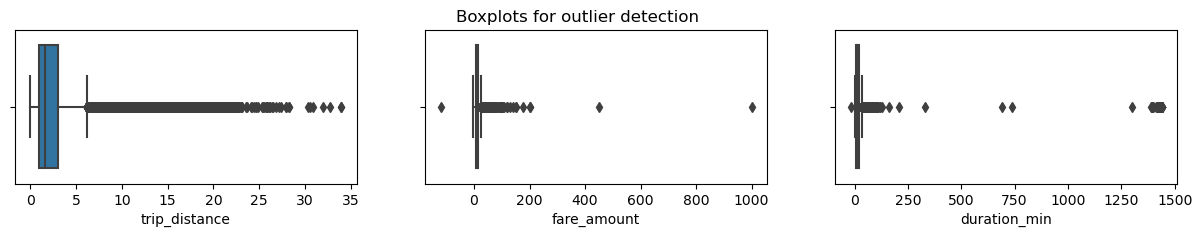

In [248]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for outlier detection')

sns.boxplot(ax=axes[0], x=df['trip_distance'])
sns.boxplot(ax=axes[1], x=df['fare_amount'])
sns.boxplot(ax=axes[2], x=df['duration_min'])

plt.show();

1. We observe outliers for all three variables. Some are extreme, but others not so much.

2. It's 30 miles from the southern tip of Staten Island to the northern end of Manhattan and that's in a straight line. With this knowledge and the distribution of the values in this column, it's reasonable to leave these values alone and not alter them. 

3. The values for `fare_amount` and `duration` definitely seem to have problematic outliers on the higher end.

####  'trip_distnce' Outliers

In [249]:
df['trip_distance'].describe()

count    22699.000000
mean         2.913313
std          3.653171
min          0.000000
25%          0.990000
50%          1.610000
75%          3.060000
max         33.960000
Name: trip_distance, dtype: float64

As it is observed, some values are 0. But there is no 0 distance values unless we assume that some customers have called for taxi but then decided to cancel thier trip. This way, the trip distance can e assumed as 0. Let's see how many 0 value trip_distance we have in our data to see if we should replace them with non-zer value such as 0.01. If not many, we can leave the untouched. 

In [250]:
(df['trip_distance']==0).sum()

148

We have 148 out of 22996 rows as 0 in the trip_distance which is relatively insignificant proportin and is unlikely to have much of an effect on the model and prediction.   

####  'fare_amount' Outliers

In [251]:
df['fare_amount'].describe()

count    22699.000000
mean        13.026629
std         13.243791
min       -120.000000
25%          6.500000
50%          9.500000
75%         14.500000
max        999.990000
Name: fare_amount, dtype: float64

- Values of 0 seem to be reasonable as customers cancelled the trip. 

- For 25 - 75% of data, we have fare_amount changing between 6.5 to 14.5. However, we observe negative values of -120 as well as very high values of 999.99 as fare_amount. This doesn't make much sence.  

- Negative values should be imputed as 0 as there is no negative fare_amount. 

- The InterQuartile Range of far_amount is 8 (IQR=8) and Q3 + (1.5 * IQR) yields 26.50. In this case, we'll use a factor of 6, which results in a cap of 62.50. We will impute the maximum values with 62.50. 

Impute values less than $0 with `0`.

In [252]:
# Replacing negative values of 'fare_amount' with 0
df['fare_amount'] = df['fare_amount'].apply(lambda x: 0 if x<0 else x)
df['fare_amount'].describe()

count    22699.000000
mean        13.033832
std         13.212462
min          0.000000
25%          6.500000
50%          9.500000
75%         14.500000
max        999.990000
Name: fare_amount, dtype: float64

Now impute the maximum value as `Q3 + (6 * IQR) which is equal to 62.50

In [253]:
 # Calculate upper threshold
q1 = df['fare_amount'].quantile(0.25)
q3 = df['fare_amount'].quantile(0.75)
iqr = q3 - q1
upper_threshold = q3 + (6 * iqr)

#Impute the high values/outliers with upper_threshold
df['fare_amount'] = df['fare_amount'].apply(lambda x: upper_threshold if x>upper_threshold else x)
df['fare_amount'].describe()

count    22699.000000
mean        12.897913
std         10.541137
min          0.000000
25%          6.500000
50%          9.500000
75%         14.500000
max         62.500000
Name: fare_amount, dtype: float64

####  'duration_min' Outliers 

In [254]:
df['duration_min'].describe()

count    22699.000000
mean        17.013777
std         61.996482
min        -16.983333
25%          6.650000
50%         11.183333
75%         18.383333
max       1439.550000
Name: duration_min, dtype: float64

The duration_min column also shows problematic values at both high and low values.

**Low Values:** We observe negative duration_min which have no values. We will impute them with 0.

**High Values:** Impute high values the same way we treted the high values in 'fare_amount' column with `Q3 + (6 * IQR) 

In [255]:
 # Calculate upper threshold
q1 = df['duration_min'].quantile(0.25)
q3 = df['duration_min'].quantile(0.75)
iqr = q3 - q1
upper_threshold = q3 + (6 * iqr)

#Impute the high values/outliers with upper_threshold
df['duration_min'] = df['duration_min'].apply(lambda x: upper_threshold if x>upper_threshold else x)
df['duration_min'].describe()

count    22699.000000
mean        14.459807
std         11.948480
min        -16.983333
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration_min, dtype: float64

### Task 3a. Feature engineering

#### Create 'mean_distance' column

When deployed, the model will not know the duration of a trip until after the trip occurs, so we cannot train a model that uses this feature. However, we can use the statistics of trips we *do* know to generalize about ones we do not know.

In this step, we create a column called 'mean_distance' that captures the mean distance for each group of trips that share pickup and dropoff points. To do so, first we create "DropOff PickUp" column which pairs the ID location of pick up and drop off columns. Then, we can obtain the average mean distance of trip for each category by grouping and map the mean distance values to all the trips having same location id of "DropOff PickUp" column. We can do the same with 'duration_min' column too.  

In [256]:
# Create `pickup_dropoff` column
df['pickup_dropoff'] = df['PULocationID'].astype(str) + ' ' + df['DOLocationID'].astype(str)
df['pickup_dropoff'].head(2)

0    100 231
1     186 43
Name: pickup_dropoff, dtype: object

In [257]:
df_pick_drop = df[['pickup_dropoff', 'trip_distance']].groupby(by='pickup_dropoff').mean()

Grouped results of "df_pick_drop" is an object of the DataFrame class. We will convert it into a dictionary using "to_dict()" and then reassign it to only contain inner dictionary meaning that we only have values from our dictionary and remove the keys. 

In [258]:
# 1. Convert `df_pick_drop` to a dictionary
grouped_dict = df_pick_drop.to_dict()

# 2. Reassign to only contain the inner dictionary
grouped_dict = grouped_dict['trip_distance']

# 3. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df['mean_distance'] = df['pickup_dropoff']

# 4. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df['mean_distance'] = df['pickup_dropoff']

# 5. Map `grouped_dict` to the `mean_distance` column
df['mean_distance'] = df['mean_distance'].map(grouped_dict)

# 6. Confirm that it worked
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_distance']]

,mean_distance
0,3.521667
4909,3.521667
16636,3.521667
18134,3.521667
19761,3.521667
20581,3.521667


#### Create 'mean_duration' column
Repeat the process used to create the 'mean_distance' column to create a 'mean_duration_min' column.

In [259]:
df_pick_drop = df.groupby('pickup_dropoff').mean(numeric_only=True)[['duration_min']]
df_pick_drop

# 1. Convert `df_pick_drop` to a dictionary
grouped_dict = df_pick_drop.to_dict()

# 2. Reassign to only contain the inner dictionary
grouped_dict = grouped_dict['duration_min']

# 3. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df['mean_duration'] = df['pickup_dropoff']

# 4. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df['mean_duration'] = df['pickup_dropoff']

# 5. Map `grouped_dict` to the `mean_distance` column
df['mean_duration'] = df['mean_duration'].map(grouped_dict)

# 6. Confirm that it worked
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_duration']]

,mean_duration
0,22.847222
4909,22.847222
16636,22.847222
18134,22.847222
19761,22.847222
20581,22.847222


#### Create 'day' and 'month' columns

Create two new columns, 'day' (name of day) and 'month' (name of month) by extracting the relevant information from the 'tpep_pickup_datetime' column.

In [260]:
# Create 'day' col
df['day'] = df['tpep_pickup_datetime'].dt.day_name()

# Create 'month' col
df['month'] =df['tpep_pickup_datetime'].dt.month_name()

#### Create 'rush_hour' column

Define rush hour as:
* Any weekday (not Saturday or Sunday) AND
* Either from 06:00-10:00 or from 16:00-20:00

Create a binary `rush_hour` column that contains a 1 if the ride was during rush hour and a 0 if it was not. Also, rush_hour will be 0 if the trip was done during the weekend. To do so, we can define a function that checks the hour column values and replaces accordingly as explained above.

In order to replace the values of a column in a pandas DataFrame based on a condition from another column, we can use the pandas loc method.

In [261]:
# Create 'rush_hour' column
df['rush_hour'] = df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
df.loc[(df['day'] == 'Saturday') | (df['day'] == 'Sunday'), 'rush_hour'] = 0

In [262]:
# define a function that checks the 'rush_hour' column values and 
def rush(hour):
    if 6 <= hour['rush_hour'] < 10:
        val = 1
    elif 16 <= hour['rush_hour'] < 20:
        val = 1
    else:
        val = 0
    return val

In [264]:
df.loc[(df['day'] != 'Saturday') & (df['day'] != 'Sunday'), 'rush_hour'] = df.apply(rush, axis=1)
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,improvement_surcharge,total_amount,duration,duration_min,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.3,16.56,0 days 00:14:04,14.066667,100 231,3.521667,22.847222,Saturday,March,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.3,20.80,0 days 00:26:30,26.500000,186 43,3.108889,24.470370,Tuesday,April,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.3,8.75,0 days 00:07:12,7.200000,262 236,0.881429,7.250000,Friday,December,0
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.3,27.69,0 days 00:30:15,30.250000,188 97,3.700000,30.250000,Sunday,May,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.3,17.80,0 days 00:16:43,16.716667,4 112,4.435000,14.616667,Saturday,April,0


### Task 4. Visualization_ScatterPlot
In order to see the relationship between fare_amount and mean_duration, we plot scatter plot using plotly. We can add line of best fit to the scatter plot as well. 

In [275]:
import plotly.express as px

# Create scatterplot with trendline
fig = px.scatter(df, x='mean_duration', y='fare_amount', trendline='ols', title='mean_duration Vs. fare_amount with Line of Best Fit')

# Choose the colors of line and marker
fig.update_traces(marker=dict(color='red'))
fig.update_traces(line=dict(color='blue'))

# Show plot
fig.show()

There is a correlation between mean_duration and fare_amount. Fare_amount increases with duration of trip. 
There are two lines of markers at fare_amount =62.5 and 52. The line of markers at 62.5 is the threshold that was imputed for the outliers. 

How about the other value at 52? We can count values  

In [281]:
df.loc[df['fare_amount']>=52]['fare_amount'].value_counts().head()

fare_amount
52.0    514
62.5     84
59.0      9
57.5      8
55.0      6
Name: count, dtype: int64

There are 514 rows with fare_amount=52. Let's examine 